<a href="https://colab.research.google.com/github/FraSeb6/Similarity_Ish_Abstract/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding Similar arXiv Abstracts (Shingling + MinHash + LSH)

Goal: detect pairs of **near-duplicate scientific abstracts** in the arXiv dataset.

Similarity measure: **Jaccard similarity**, estimated efficiently with **MinHash**, and
scaled to large data with **Locality-Sensitive Hashing (LSH)**.

Pipeline: `shingling -> MinHash signatures -> LSH candidate pairs -> validation (precision & recall) -> scalability`.

## 0. Setup & Configuration

In [49]:
import os
import json
import time
import zlib
import random
import zipfile
import itertools
from collections import defaultdict 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm   # simple progress bar for the long loops

print("Setup ready. NumPy version:", np.__version__)

Setup ready. NumPy version: 2.5.0


In [50]:
SEED = 42
random.seed(SEED)      
np.random.seed(SEED) 

DATASET   = "Cornell-University/arxiv"
JSON_FILE = "arxiv-metadata-oai-snapshot.json"

USE_SUBSAMPLE  = True      # True  -> work on a small slice (fast, for testing)
                           # False -> work on the full dataset
SUBSAMPLE_SIZE = 50_000    


MIN_ABSTRACT_WORDS = 20    

# ---------- Shingling ----------
SHINGLE_K = 9             # character-level k-shingles (k=9 chosen empirically, see Section 2)

# ---------- MinHash ----------
N_HASHES = 100            # number of hash functions = length of each MinHash signature
PRIME    = 2_147_483_647  # a large prime (2^31 - 1) used by the hash functions h(x) = (a*x + b) % PRIME

# ---------- LSH target ----------
TARGET_THRESHOLD = 0.5    # we want LSH to catch pairs whose Jaccard similarity is >= 0.5

mode = f"SUBSAMPLE ({SUBSAMPLE_SIZE:,} docs)" if USE_SUBSAMPLE else "FULL DATASET"
print("Mode:", mode)
print(f"Signature length = {N_HASHES} | target Jaccard threshold = {TARGET_THRESHOLD}")

Mode: SUBSAMPLE (50,000 docs)
Signature length = 100 | target Jaccard threshold = 0.5


## 1. Data Ingestion (streaming)


In [51]:
os.environ["KAGGLE_USERNAME"] = "xxxxxx"
os.environ["KAGGLE_KEY"]      = "xxxxxx"

!pip install -q kaggle
!kaggle datasets download -d {DATASET}

with zipfile.ZipFile("arxiv.zip") as z:
    z.extract(JSON_FILE)

print("Dataset ready:", JSON_FILE)


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset ready: arxiv-metadata-oai-snapshot.json


In [52]:
def load_abstracts(path, use_subsample, subsample_size, min_words):
    ids = []          
    abstracts = []    
    n_seen = 0        

    with open(path, encoding="utf-8") as f:
        for line in f:                               
            if use_subsample and n_seen >= subsample_size:
                break                                 
            n_seen += 1

            record = json.loads(line)                  
            abstract = record["abstract"]            

            if len(abstract.split()) < min_words:     
                continue                             

            ids.append(record["id"])
            abstracts.append(abstract)

    print(f"Read {n_seen:,} lines, kept {len(abstracts):,} abstracts "
          f"(dropped {n_seen - len(abstracts):,} too short)")

    
    return pd.DataFrame({"id": ids, "abstract": abstracts})

In [53]:
t0 = time.time()
df = load_abstracts(
    JSON_FILE,
    use_subsample=USE_SUBSAMPLE,
    subsample_size=SUBSAMPLE_SIZE,
    min_words=MIN_ABSTRACT_WORDS,
)
print(f"Loaded in {time.time() - t0:.1f}s")

df.head(3)

Read 50,000 lines, kept 49,327 abstracts (dropped 673 too short)
Loaded in 0.6s


,id,abstract
0,0704.0001,A fully differential calculation in perturba...
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,0704.0003,The evolution of Earth-Moon system is descri...


## 2. Shingling

We turn each abstract into a **set of k-shingles**: every substring of `k` consecutive characters.
Two abstracts that share many shingles are similar, so the **Jaccard similarity of their shingle
sets** is exactly what we want to measure.

**Why character-level k=9?** We actually tried two values and let the validation results decide:

- With **k=5** the shingles are too common — short substrings like `" the"`, `"tion"` or `"ing "`
  appear in almost every English abstract. Their MinHash values then collide across unrelated
  documents, which floods LSH with false positives: about **50k candidate pairs**, **precision only
  a few percent**, and one giant "cluster" of **681 completely unrelated papers**.
- With **k=9** the shingles are **distinctive**: a 9-character substring is far rarer, so unrelated
  abstracts stop colliding. Candidate pairs dropped to a **few hundred**, **precision jumped to
  ~50-60%**, recall stayed high, and the largest cluster became a **genuine set of near-identical
  papers**.

So k=9 is our choice, and it matches the textbook guidance that longer/normal documents need a
larger k to keep shingles specific. (This is also a nice illustration of *why* we measure quality:
without precision and recall we would never have spotted the k=5 problem.)



In [54]:
def normalize(text):
   
    return " ".join(text.lower().split())


def shingle_set(text, k=SHINGLE_K):
    text = normalize(text)                             
    shingles = set()                                    
    for i in range(len(text) - k + 1):                 
        piece = text[i:i + k]                          
        h = zlib.crc32(piece.encode()) & 0x7FFFFFFF    
        shingles.add(h)                             
    return shingles

In [55]:
demo_text = df["abstract"].iloc[0]
demo_shingles = shingle_set(demo_text)

print("Abstract length (characters):", len(normalize(demo_text)))
print(f"Number of unique {SHINGLE_K}-shingles:", len(demo_shingles))
print("A few hashed shingles:       ", list(demo_shingles)[:5])

Abstract length (characters): 980
Number of unique 9-shingles: 899
A few hashed shingles:        [1227995139, 988133381, 462764050, 1520732184, 1065730073]


## 3. MinHash

Comparing full shingle sets for every pair of documents would be far too expensive. **MinHash**
compresses each document's shingle set into a short **signature** of `N_HASHES` numbers.


In [56]:
A = np.random.randint(1, PRIME, size=N_HASHES, dtype=np.uint64)   
B = np.random.randint(0, PRIME, size=N_HASHES, dtype=np.uint64)   

print("Created", N_HASHES, "hash functions.")

Created 100 hash functions.


In [57]:
def minhash_signature(shingles):
    sig = np.full(N_HASHES, np.iinfo(np.uint64).max, dtype=np.uint64)
    for x in shingles:                      
        h = (A * x + B) % PRIME              
        sig = np.minimum(sig, h)            
    return sig                              

In [58]:
def build_signatures(frame):
    n = len(frame)
    signatures = np.zeros((n, N_HASHES), dtype=np.uint64)
    for i, text in enumerate(tqdm(frame["abstract"], desc="MinHash")):
        signatures[i] = minhash_signature(shingle_set(text))
    return signatures

In [59]:
t0 = time.time()
signatures = build_signatures(df)
t_minhash_full = time.time() - t0         
print(f"Built {signatures.shape[0]:,} signatures of length {signatures.shape[1]} "
      f"in {t_minhash_full:.1f}s")


print("Example signature (first 10 values):", signatures[0][:10])

MinHash: 100%|██████████| 49327/49327 [00:55<00:00, 895.57it/s] 

Built 49,327 signatures of length 100 in 55.1s
Example signature (first 10 values): [5836694 6212603 3619743 2039971 3563924 1326447 1463078  917629 1382929
  542856]


## 4. LSH (Locality-Sensitive Hashing)


In [60]:
def choose_bands_rows(n_hashes, target_threshold):
    best = None
    for b in range(1, n_hashes + 1):
        if n_hashes % b != 0:                  
            continue
        r = n_hashes // b                      
        t = (1 / b) ** (1 / r)                 
        if best is None or abs(t - target_threshold) < abs(best[2] - target_threshold):
            best = (b, r, t)                  
    return best


BANDS, ROWS, LSH_THRESHOLD = choose_bands_rows(N_HASHES, TARGET_THRESHOLD)
print(f"Chosen split: {BANDS} bands x {ROWS} rows  (b * r = {BANDS * ROWS})")
print(f"Target threshold = {TARGET_THRESHOLD} | actual LSH threshold = {LSH_THRESHOLD:.3f}")

Chosen split: 20 bands x 5 rows  (b * r = 100)
Target threshold = 0.5 | actual LSH threshold = 0.549


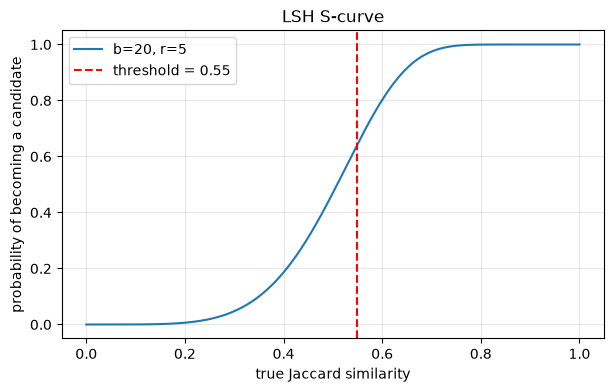

In [61]:

s = np.linspace(0, 1, 200)
prob = 1 - (1 - s ** ROWS) ** BANDS

plt.figure(figsize=(7, 4))
plt.plot(s, prob, label=f"b={BANDS}, r={ROWS}")
plt.axvline(LSH_THRESHOLD, color="red", linestyle="--", label=f"threshold = {LSH_THRESHOLD:.2f}")
plt.xlabel("true Jaccard similarity")
plt.ylabel("probability of becoming a candidate")
plt.title("LSH S-curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [62]:
def lsh_candidate_pairs(signatures, bands, rows):
    num_docs = signatures.shape[0]
    candidates = set()                              
    for band in range(bands):                       
        start = band * rows                         
        buckets = defaultdict(list)                 
        for doc in range(num_docs):
            key = signatures[doc, start:start + rows].tobytes()  
            buckets[key].append(doc)                
        for docs in buckets.values():
            if len(docs) > 1:                       
                for pair in itertools.combinations(docs, 2):
                    candidates.add(pair)            
    return candidates

In [63]:
t0 = time.time()
candidate_pairs = lsh_candidate_pairs(signatures, BANDS, ROWS)
t_lsh_full = time.time() - t0              
print(f"Found {len(candidate_pairs):,} candidate pairs in {t_lsh_full:.1f}s")

Found 380 candidate pairs in 0.8s


## 5. Validation: Precision & Recall


In [64]:
def jaccard(set_a, set_b):
    inter = len(set_a & set_b)                 
    union = len(set_a) + len(set_b) - inter    
    return inter / union if union else 0.0      


def ground_truth_pairs(frame, n_docs, threshold):
    shingle_sets = [shingle_set(frame["abstract"].iloc[i]) for i in range(n_docs)]
    truly_similar = set()
    for i in tqdm(range(n_docs), desc="Ground truth"):
        for j in range(i + 1, n_docs):                       
            if jaccard(shingle_sets[i], shingle_sets[j]) >= threshold:
                truly_similar.add((i, j))                   
    return truly_similar, shingle_sets

In [65]:
GROUND_TRUTH_SIZE = 4000   

t0 = time.time()
truly_similar, gt_shingles = ground_truth_pairs(df, GROUND_TRUTH_SIZE, LSH_THRESHOLD)
print(f"Brute force over {GROUND_TRUTH_SIZE:,} docs took {time.time() - t0:.1f}s")
print(f"Truly similar pairs (true Jaccard >= {LSH_THRESHOLD:.2f}): {len(truly_similar):,}")

Ground truth: 100%|██████████| 4000/4000 [01:00<00:00, 66.04it/s] 


Brute force over 4,000 docs took 61.3s
Truly similar pairs (true Jaccard >= 0.55): 7


In [66]:

lsh_in_subset = {(i, j) for (i, j) in candidate_pairs
                 if i < GROUND_TRUTH_SIZE and j < GROUND_TRUTH_SIZE}

found_and_true = lsh_in_subset & truly_similar      

precision = len(found_and_true) / len(lsh_in_subset) if lsh_in_subset else 0.0
recall    = len(found_and_true) / len(truly_similar) if truly_similar else 0.0

print(f"LSH candidate pairs inside the subsample: {len(lsh_in_subset):,}")
print(f"Precision (subsample only): {precision:.1%}")
print(f"Recall:                     {recall:.1%}   (of the truly similar pairs, how many LSH caught)")

LSH candidate pairs inside the subsample: 12
Precision (subsample only): 50.0%
Recall:                     85.7%   (of the truly similar pairs, how many LSH caught)


Global precision over all 380 candidate pairs: 63.2%


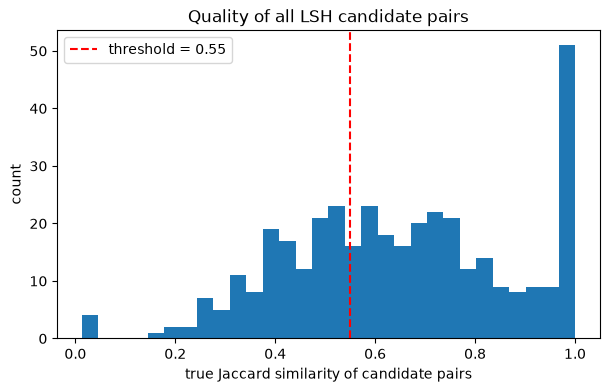

In [67]:
shingle_cache = {}
def doc_shingles(doc):
    if doc not in shingle_cache:
        shingle_cache[doc] = shingle_set(df["abstract"].iloc[doc])
    return shingle_cache[doc]

all_sims = np.array([jaccard(doc_shingles(i), doc_shingles(j)) for (i, j) in candidate_pairs])

global_precision = (all_sims >= LSH_THRESHOLD).mean()
print(f"Global precision over all {len(candidate_pairs):,} candidate pairs: {global_precision:.1%}")

plt.figure(figsize=(7, 4))
plt.hist(all_sims, bins=30)
plt.axvline(LSH_THRESHOLD, color="red", linestyle="--", label=f"threshold = {LSH_THRESHOLD:.2f}")
plt.xlabel("true Jaccard similarity of candidate pairs")
plt.ylabel("count")
plt.title("Quality of all LSH candidate pairs")
plt.legend()
plt.show()

## 6. Duplicate Clusters

So far we have **pairs**. But a paper often appears in several near-identical versions, so the same
abstract can be paired with many others. We can recover these **groups** with a tiny bit of graph
theory:

- build a graph where each **node** is a document and each **edge** is an LSH candidate pair;
- the **connected components** of that graph are the clusters of near-duplicate abstracts.

We find the components with a simple depth-first traversal (no external library). Each cluster is
typically a set of versions of the same paper.

In [68]:
def connected_components(pairs):
    graph = defaultdict(set)
    for i, j in pairs:
        graph[i].add(j)
        graph[j].add(i)

    visited = set()
    components = []
    for start in graph:                       
        if start in visited:
            continue                         
        stack = [start]
        component = []
        while stack:
            node = stack.pop()                
            if node in visited:
                continue
            visited.add(node)
            component.append(node)
            stack.extend(graph[node] - visited)   
        components.append(component)
    return components

In [69]:
clusters = connected_components(candidate_pairs)
print(f"Found {len(clusters):,} duplicate groups (each is a set of 2+ near-identical abstracts)")

sizes = sorted((len(c) for c in clusters), reverse=True)
print("Ten largest cluster sizes:", sizes[:10])

Found 337 duplicate groups (each is a set of 2+ near-identical abstracts)
Ten largest cluster sizes: [7, 4, 4, 3, 3, 3, 3, 3, 3, 3]


In [70]:
biggest = max(clusters, key=len)
print(f"Largest cluster has {len(biggest)} abstracts:\n")
for doc in sorted(biggest)[:5]:                       
    snippet = df["abstract"].iloc[doc][:120].strip()
    print(f"  id={df['id'].iloc[doc]}  |  {snippet} ...")

Largest cluster has 7 abstracts:

  id=0710.4022  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4023  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4024  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4025  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4028  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...


## 7. Scalability

The assignment requires the pipeline to scale to the full 3 millions abstracts, so we check how the running
time grows. We re-run the two heavy stages — **MinHash** and **LSH** — on increasingly large prefixes
of the dataset (5k, 10k, 20k, 40k documents) and time each stage separately.

We then append **one final point**: the run on the *whole* loaded dataset. We do not recompute it —
we reuse the times already measured in Sections 3 and 4. So this last row reflects whatever was
actually processed: ~49k abstracts in subsample mode, or 3 millions when `USE_SUBSAMPLE = False`.

If the implementation is sound, both stages grow **roughly linearly** in the number of documents `n`,
with no quadratic blow-up — which is what lets the same code run on the full dataset unchanged.

In [71]:
def benchmark(frame, sizes):
    rows = []
    for n in sizes:
        sub = frame.iloc[:n]                              

        t0 = time.time()
        sig = build_signatures(sub)                       
        t_minhash = time.time() - t0

        t1 = time.time()
        cands = lsh_candidate_pairs(sig, BANDS, ROWS)     
        t_lsh = time.time() - t1

        rows.append({"n": n, "minhash_s": t_minhash, "lsh_s": t_lsh,
                     "total_s": t_minhash + t_lsh, "candidates": len(cands)})
        print(f"n={n:>7,} | minhash {t_minhash:6.1f}s | lsh {t_lsh:5.1f}s | candidates {len(cands):>7,}")
    return pd.DataFrame(rows)


SIZES = [n for n in (5_000, 10_000, 20_000, 40_000) if n <= len(df)]
bench = benchmark(df, SIZES)

full_row = {"n": len(df), "minhash_s": t_minhash_full, "lsh_s": t_lsh_full,
            "total_s": t_minhash_full + t_lsh_full, "candidates": len(candidate_pairs)}
bench = pd.concat([bench, pd.DataFrame([full_row])], ignore_index=True)
bench

MinHash: 100%|██████████| 5000/5000 [00:05<00:00, 906.50it/s]


n=  5,000 | minhash    5.5s | lsh   0.1s | candidates      15


MinHash: 100%|██████████| 10000/10000 [00:10<00:00, 940.71it/s]


n= 10,000 | minhash   10.6s | lsh   0.1s | candidates      35


MinHash: 100%|██████████| 20000/20000 [00:20<00:00, 979.18it/s] 


n= 20,000 | minhash   20.4s | lsh   0.4s | candidates      88


MinHash: 100%|██████████| 40000/40000 [00:43<00:00, 917.25it/s] 


n= 40,000 | minhash   43.6s | lsh   0.8s | candidates     298


,n,minhash_s,lsh_s,total_s,candidates
0,5000,5.516839,0.107293,5.624132,15
1,10000,10.631355,0.104899,10.736254,35
2,20000,20.426227,0.369621,20.795848,88
3,40000,43.609834,0.840229,44.450063,298
4,49327,55.080563,0.792609,55.873172,380
